<a href="https://colab.research.google.com/github/427paul/AI_Agent/blob/main/%5BBDA%5D_6%E1%84%8C%E1%85%AE%E1%84%8E%E1%85%A1_%E1%84%90%E1%85%A6%E1%86%A8%E1%84%89%E1%85%B3%E1%84%90%E1%85%B3%E1%84%87%E1%85%AE%E1%86%AB%E1%84%89%E1%85%A5%E1%86%A8_%E1%84%83%E1%85%B5%E1%86%B8%E1%84%85%E1%85%A5%E1%84%82%E1%85%B5%E1%86%BC%E1%84%80%E1%85%B5%E1%84%8E%E1%85%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6주차 | 텍스트 분석을 위한 딥러닝 기초

> **학습목표**  
> 1. 전통적 텍스트 분류(TF-IDF + ML)의 한계를 이해하고, 딥러닝이 왜 필요한지 설명할 수 있다.  
> 2. 신경망의 핵심 구조(입력→은닉→출력, 활성화함수, 손실함수)를 그림과 코드로 이해한다.  
> 3. 순서가 있는 텍스트 데이터를 다루는 RNN/LSTM의 원리를 이해한다.  
> 4. PyTorch로 간단한 LSTM 감성 분류 모델을 직접 구현하고 학습시킨다.

### 커리큘럼 위치

| 주차 | 주제 | 핵심 키워드 |
|------|------|------------|
| 3주차 | 텍스트 수치화 | BoW, TF-IDF |
| 4주차 | 텍스트 분류 | 나이브 베이즈, 로지스틱 회귀 |
| 5주차 | 단어 임베딩 | Word2Vec, 의미 벡터 |
| **6주차** | **딥러닝 기초** | **신경망, RNN, LSTM** |
| 7주차 | Transformer | Self-Attention, 인코더-디코더 |
| 8주차 | GPT 모델 | 사전학습, 파인튜닝, 프롬프트 |

---
## 1. 왜 텍스트 분석에 딥러닝이 필요한가?

### 🤔 지금까지 배운 방법의 한계

4주차에서 TF-IDF + 로지스틱 회귀로 감성 분류를 했습니다.  
잘 작동하지만, **근본적인 한계**가 있습니다.

In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 35.3 MB/s eta 0:00:00


In [2]:
import koreanize_matplotlib

In [3]:
# 1️⃣ 한계 1: 단어 순서를 무시한다

sentence_a = "영화가 지루하지 않고 재미있다"   # 긍정
sentence_b = "영화가 재미있지 않고 지루하다"   # 부정

# BOW/TF-IDF로 보면?
from collections import Counter

bow_a = Counter(sentence_a.split())
bow_b = Counter(sentence_b.split())

print(f"문장A (긍정): {bow_a}")
print(f"문장B (부정): {bow_b}")
print()
print("⚠️ 거의 같은 단어로 구성 → BOW/TF-IDF로는 구별 불가!")
print("   '않고'가 어디에 위치하느냐에 따라 의미가 완전히 반대!")

문장A (긍정): Counter({'영화가': 1, '지루하지': 1, '않고': 1, '재미있다': 1})
문장B (부정): Counter({'영화가': 1, '재미있지': 1, '않고': 1, '지루하다': 1})

⚠️ 거의 같은 단어로 구성 → BOW/TF-IDF로는 구별 불가!
   '않고'가 어디에 위치하느냐에 따라 의미가 완전히 반대!


In [4]:
# 2️⃣ 한계 2: 문맥을 이해하지 못한다

examples = [
    ("사과를 먹었다", "사과 = 과일"),
    ("진심으로 사과한다", "사과 = 사죄"),
]

print("같은 '사과'인데 의미가 다릅니다:")
for sentence, meaning in examples:
    print(f"{sentence} → {meaning}")

print()
print("⚠️ TF-IDF는 '사과'를 항상 같은 단어로 취급!")
print("   주변 단어(문맥)를 보고 의미를 파악해야 → 딥러닝이 필요")

같은 '사과'인데 의미가 다릅니다:
사과를 먹었다 → 사과 = 과일
진심으로 사과한다 → 사과 = 사죄

⚠️ TF-IDF는 '사과'를 항상 같은 단어로 취급!
   주변 단어(문맥)를 보고 의미를 파악해야 → 딥러닝이 필요


### 전통 ML vs 딥러닝 비교

| 구분 | 전통 ML (TF-IDF + 분류기) | 딥러닝 (RNN/Transformer) |
|------|--------------------------|-------------------------|
| 단어 표현 | 빈도 기반 (희소 벡터) | 임베딩 (밀집 벡터) |
| 단어 순서 | ❌ 무시 | ✅ 반영 |
| 문맥 이해 | ❌ 불가 | ✅ 가능 |
| 특성 추출 | 사람이 직접 설계 | 모델이 자동 학습 |
| 데이터 양 | 적어도 OK | 많을수록 유리 |
| 학습 시간 | 빠름 | 느림 (GPU 필요) |

> 💡 **핵심**: 딥러닝은 **단어의 순서와 문맥**을 이해할 수 있다!

---
## 2. 신경망(Neural Network) 기초 이론

### 🧠 신경망 = 입력 → 변환 → 출력

신경망은 데이터를 입력받아 여러 단계의 **변환(가중치 곱셈 + 활성화)**을 거쳐 결과를 출력합니다.

```
    입력층          은닉층          출력층
   (Input)        (Hidden)       (Output)

   x1 ─────┐    ┌─── h1 ───┐
            ├────┤          ├──── y (긍정/부정)
   x2 ─────┤    └─── h2 ───┘
            │
   x3 ─────┘

         W1 (가중치)    W2 (가중치)
```

각 화살표에는 **가중치(weight)**가 있고, 학습 = 이 가중치를 최적화하는 과정입니다.

### 2-1. 핵심 개념 4가지

| 개념 | 설명 | 비유 |
|------|------|------|
| **가중치 (Weight)** | 입력에 곱해지는 학습 가능한 값 | 각 단어의 "중요도 점수" |
| **편향 (Bias)** | 가중합에 더해지는 상수 | 기본 점수 (가산점) |
| **활성화 함수** | 비선형 변환 (ReLU, Sigmoid 등) | "이 정도면 활성화시킬까?" 판단 |
| **손실 함수** | 예측과 정답의 차이 (줄여야 할 값) | 시험 점수의 감점 |

In [5]:
# 3️⃣ 신경망의 기본 연산을 NumPy로 이해하기
import numpy as np

# === 하나의 뉴런 (Neuron) ===
# y = activation(W · x + b)

# 입력: 단어 임베딩 3차원이라고 가정
x = np.array([0.5, -0.3, 0.8])  # 입력 벡터
W = np.array([0.2, 0.7, -0.5])  # 가중치
b = 0.1                          # 편향

# Step 1: 가중합 (weighted sum)
z = np.dot(W, x) + b
print(f"입력 x: {x}")
print(f"가중치 W: {W}")
print(f"가중합 z = W·x + b = {z:.4f}")

입력 x: [ 0.5 -0.3  0.8]
가중치 W: [ 0.2  0.7 -0.5]
가중합 z = W·x + b = -0.4100


In [6]:
# 4️⃣ 활성화 함수 — 비선형성을 부여하는 핵심
import numpy as np

# Sigmoid: 0~1 사이 값으로 변환 (확률 해석 가능)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ReLU: 음수는 0, 양수는 그대로 (가장 많이 사용)
def relu(z):
    return np.maximum(0, z)

z_values = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])

print("z값      | Sigmoid  | ReLU")
print("-" * 35)
for z in z_values:
    print(f"{z:+6.1f}   | {sigmoid(z):.4f}   | {relu(z):.1f}")

print()
print("💡 Sigmoid: 마지막 출력층에서 확률(긍정/부정)을 구할 때 사용")
print("💡 ReLU: 은닉층에서 주로 사용 (계산이 빠르고 학습이 잘 됨)")

z값      | Sigmoid  | ReLU
-----------------------------------
  -2.0   | 0.1192   | 0.0
  -0.5   | 0.3775   | 0.0
  +0.0   | 0.5000   | 0.0
  +0.5   | 0.6225   | 0.5
  +2.0   | 0.8808   | 2.0

💡 Sigmoid: 마지막 출력층에서 확률(긍정/부정)을 구할 때 사용
💡 ReLU: 은닉층에서 주로 사용 (계산이 빠르고 학습이 잘 됨)


### 2-2. 학습 과정 = 손실을 줄이는 것

```
1. 입력 데이터를 신경망에 넣는다           (순전파, Forward)
2. 예측값과 정답을 비교하여 손실을 계산한다   (Loss 계산)
3. 손실을 줄이는 방향으로 가중치를 조정한다   (역전파, Backward)
4. 1~3을 반복한다                        (학습 루프)
```

이 과정을 **경사 하강법(Gradient Descent)**이라고 합니다.

> 💡 **비유**: 눈을 감고 산에서 내려오기  
> 발밑의 경사(기울기)를 느끼며, 가장 가파르게 내려가는 방향으로 한 발씩 이동  
> → 가장 낮은 곳(최소 손실)에 도달하는 것이 목표!

In [7]:
# 5️⃣ 손실 함수 예시: Binary Cross-Entropy
import numpy as np

def binary_cross_entropy(y_true, y_pred):
    # y_pred가 0이나 1이 되지 않도록 클리핑
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 정답: 긍정(1)
y_true = 1

# 다양한 예측값에 대한 손실
print("정답이 '긍정(1)'일 때:")
print(f"  예측 0.9 (잘 맞춤) → 손실: {binary_cross_entropy(y_true, 0.9):.4f}")
print(f"  예측 0.5 (애매)    → 손실: {binary_cross_entropy(y_true, 0.5):.4f}")
print(f"  예측 0.1 (틀림)    → 손실: {binary_cross_entropy(y_true, 0.1):.4f}")
print()
print("→ 예측이 정답에 가까울수록 손실이 작다!")
print("→ 학습 = 이 손실을 줄이는 방향으로 가중치를 업데이트하는 것")

정답이 '긍정(1)'일 때:
  예측 0.9 (잘 맞춤) → 손실: 0.1054
  예측 0.5 (애매)    → 손실: 0.6931
  예측 0.1 (틀림)    → 손실: 2.3026

→ 예측이 정답에 가까울수록 손실이 작다!
→ 학습 = 이 손실을 줄이는 방향으로 가중치를 업데이트하는 것


---
## 3. PyTorch 기초 — 딥러닝 프레임워크

PyTorch는 딥러닝 모델을 만들고 학습시키는 **가장 인기 있는 프레임워크**입니다.

핵심 개념 3가지:
1. **Tensor**: 다차원 배열 (NumPy의 ndarray와 유사, GPU 연산 가능)
2. **자동 미분 (autograd)**: 기울기를 자동으로 계산
3. **nn.Module**: 신경망 레이어를 조합하는 구조

In [8]:
# 6️⃣ PyTorch 설치 확인 & Tensor 기초
import torch
print(f"PyTorch 버전: {torch.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")

# Tensor 생성
x = torch.tensor([1.0, 2.0, 3.0])
print(f"\nTensor: {x}")
print(f"형태: {x.shape}")
print(f"타입: {x.dtype}")

PyTorch 버전: 2.10.0+cpu
GPU 사용 가능: False

Tensor: tensor([1., 2., 3.])
형태: torch.Size([3])
타입: torch.float32


In [9]:
# 7️⃣ Tensor 연산 — NumPy와 거의 동일
import torch

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print(f"덧셈: {a + b}")
print(f"곱셈: {a * b}")
print(f"내적: {torch.dot(a, b)}")

# 행렬 생성
matrix = torch.tensor([[1, 2], [3, 4], [5, 6]], dtype=torch.float32)
print(f"\n행렬 형태: {matrix.shape}")  # (3, 2)

# NumPy ↔ Tensor 변환
import numpy as np
np_array = np.array([1.0, 2.0, 3.0])
tensor_from_np = torch.from_numpy(np_array)
np_from_tensor = a.numpy()
print(f"\nNumPy → Tensor: {tensor_from_np}")
print(f"Tensor → NumPy: {np_from_tensor}")

덧셈: tensor([5., 7., 9.])
곱셈: tensor([ 4., 10., 18.])
내적: 32.0

행렬 형태: torch.Size([3, 2])

NumPy → Tensor: tensor([1., 2., 3.], dtype=torch.float64)
Tensor → NumPy: [1. 2. 3.]


In [10]:
# 8️⃣ 자동 미분 — 학습의 핵심 (개념만 이해)
import torch

# requires_grad=True → 이 텐서에 대한 기울기를 추적하겠다!
w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)

# 순전파: y = w * x
y = w * x
print(f"w = {w.item()}, x = {x.item()}")
print(f"y = w * x = {y.item()}")

# 역전파: dy/dw 계산
y.backward()
print(f"dy/dw = {w.grad.item()}")  # x의 값인 3.0

print()
print("💡 w.grad = 3.0 → w를 1 늘리면 y가 3 늘어난다는 뜻")
print("💡 이 기울기 정보로 가중치를 업데이트하는 것이 '학습'!")

w = 2.0, x = 3.0
y = w * x = 6.0
dy/dw = 3.0

💡 w.grad = 3.0 → w를 1 늘리면 y가 3 늘어난다는 뜻
💡 이 기울기 정보로 가중치를 업데이트하는 것이 '학습'!


In [11]:
# 9️⃣ nn.Module로 간단한 신경망 만들기
import torch
import torch.nn as nn

# 2층 신경망 (입력 → 은닉 → 출력)
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)   # 입력→은닉
        self.relu = nn.ReLU()                               # 활성화
        self.layer2 = nn.Linear(hidden_size, output_size)  # 은닉→출력
        self.sigmoid = nn.Sigmoid()                         # 확률 출력

    def forward(self, x):
        x = self.layer1(x)    # 가중합
        x = self.relu(x)      # 활성화
        x = self.layer2(x)    # 가중합
        x = self.sigmoid(x)   # 0~1 확률
        return x

# 모델 생성: 입력 10차원, 은닉 5차원, 출력 1차원
model = SimpleNN(input_size=10, hidden_size=5, output_size=1)
print(model)

# 테스트 입력
dummy_input = torch.randn(1, 10)  # 배치 1개, 10차원
output = model(dummy_input)
print(f"\n입력 형태: {dummy_input.shape}")
print(f"출력 (확률): {output.item():.4f}")

SimpleNN(
  (layer1): Linear(in_features=10, out_features=5, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=5, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

입력 형태: torch.Size([1, 10])
출력 (확률): 0.5092


---
## 4. RNN — 순서를 이해하는 신경망

### 📖 핵심 아이디어

일반 신경망은 입력을 **독립적으로** 처리합니다.  
하지만 텍스트는 **순서**가 중요합니다!

**RNN(Recurrent Neural Network)**은 이전 단어의 정보를 **기억**하면서  
다음 단어를 처리하는 구조입니다.

```
"나는   영화를   정말    좋아한다"
  ↓      ↓       ↓        ↓
[RNN] → [RNN] → [RNN] → [RNN] → 긍정!
  h0      h1      h2      h3
          ↑               ↑
     h0의 정보가      h0~h2의 정보가
     여기에 전달됨     누적되어 전달됨
```

> 💡 **h (hidden state)** = "지금까지 읽은 내용의 요약"  
> 사람이 문장을 왼쪽에서 오른쪽으로 읽으며 의미를 누적하는 것과 같습니다!

### 4-1. RNN의 수학적 표현

각 시점 t에서:

```
h_t = tanh(W_hh · h_{t-1}  +  W_xh · x_t  +  b)
       ↑          ↑               ↑
    활성화    이전 상태 반영     현재 입력 반영
```

- `x_t`: 현재 시점의 입력 (현재 단어의 임베딩)
- `h_{t-1}`: 이전 시점의 은닉 상태 (이전까지의 문맥 요약)
- `h_t`: 현재 시점의 은닉 상태 (현재까지의 문맥 요약)
- `W_hh`, `W_xh`: 학습되는 가중치

In [12]:
# 🔟 RNN 동작을 NumPy로 직접 구현해보기
import numpy as np

np.random.seed(42)

# 설정
embedding_dim = 4   # 단어 임베딩 차원
hidden_dim = 3      # 은닉 상태 차원

# 가중치 (실제로는 학습되지만, 여기선 랜덤 초기화)
W_xh = np.random.randn(hidden_dim, embedding_dim) * 0.1  # 입력→은닉
W_hh = np.random.randn(hidden_dim, hidden_dim) * 0.1     # 은닉→은닉
b = np.zeros(hidden_dim)                                   # 편향

# 가상의 문장: "나는 영화를 좋아한다" (3단어, 각 4차원 임베딩)
sentence = {
    "나는":     np.array([0.5, -0.3, 0.8, 0.1]),
    "영화를":   np.array([0.2, 0.7, -0.1, 0.4]),
    "좋아한다": np.array([0.9, 0.3, 0.5, -0.2]),
}

# RNN 순전파 (한 단어씩 처리)
h = np.zeros(hidden_dim)  # 초기 은닉 상태 (0으로 시작)

print("=== RNN 순전파 과정 ===")
print(f"초기 h_0: {h}\n")

for t, (word, x_t) in enumerate(sentence.items()):
    # h_t = tanh(W_xh · x_t + W_hh · h_{t-1} + b)
    h = np.tanh(W_xh @ x_t + W_hh @ h + b)
    print(f"시점 {t+1}: '{word}'")
    print(f"  입력 x_{t+1}: {x_t}")
    print(f"  은닉 h_{t+1}: {np.round(h, 4)}")
    print()

print(f"최종 은닉 상태 h_3: {np.round(h, 4)}")
print("→ 이 벡터가 전체 문장의 '요약'이 됩니다!")
print("→ 이걸 분류층(Linear)에 넣으면 긍정/부정 판단 가능")

=== RNN 순전파 과정 ===
초기 h_0: [0. 0. 0.]

시점 1: '나는'
  입력 x_1: [ 0.5 -0.3  0.8  0.1]
  은닉 h_1: [ 0.0957  0.1286 -0.0813]

시점 2: '영화를'
  입력 x_2: [ 0.2  0.7 -0.1  0.4]
  은닉 h_2: [ 0.0464 -0.0271 -0.0242]

시점 3: '좋아한다'
  입력 x_3: [ 0.9  0.3  0.5 -0.2]
  은닉 h_3: [ 0.0529  0.0349 -0.0437]

최종 은닉 상태 h_3: [ 0.0529  0.0349 -0.0437]
→ 이 벡터가 전체 문장의 '요약'이 됩니다!
→ 이걸 분류층(Linear)에 넣으면 긍정/부정 판단 가능


### 4-2. RNN의 한계: 장기 의존성 문제

```
"나는 어제 친구와 함께 강남에 있는 새로 생긴 이탈리안 레스토랑에서
 정말 맛있는 파스타를 먹었는데, 그 집은 분위기도 좋고 가격도
 합리적이어서 다음에 또 가고 싶다"

  ↑ 첫 단어 "나는"의 정보가 끝까지 전달되어야 하는데...
  → 문장이 길어질수록 앞쪽 정보가 점점 사라짐! (기울기 소실)
```

이 문제를 해결한 것이 → **LSTM** (Long Short-Term Memory)

---
## 5. LSTM — 장기 기억을 가진 RNN

### 🔑 LSTM의 핵심: "게이트(Gate)" 메커니즘

LSTM은 3개의 게이트로 정보의 흐름을 제어합니다:

```
┌──────────────────────────────────────────────────┐
│                   LSTM 셀                         │
│                                                   │
│  ① 망각 게이트 (Forget Gate)                       │
│     → "이전 기억 중 어떤 것을 잊을까?"              │
│     → 예: "주어가 바뀌면 이전 주어 정보를 잊자"     │
│                                                   │
│  ② 입력 게이트 (Input Gate)                        │
│     → "새로운 정보 중 어떤 것을 기억할까?"           │
│     → 예: "새 주어 '영화가'를 기억하자"            │
│                                                   │
│  ③ 출력 게이트 (Output Gate)                       │
│     → "기억 중 어떤 것을 내보낼까?"                 │
│     → 예: "지금은 '감성' 관련 정보를 내보내자"     │
└──────────────────────────────────────────────────┘
```

> 💡 **비유**: LSTM은 **노트 필기하면서 강의를 듣는 학생**  
> - 망각 게이트: 필요없는 내용은 줄 긋기 (삭제)  
> - 입력 게이트: 중요한 내용만 골라서 적기 (추가)  
> - 출력 게이트: 시험에 나올 것만 답안지에 쓰기 (출력)

In [13]:
# 1️⃣1️⃣ PyTorch LSTM 기본 사용법
import torch
import torch.nn as nn

# LSTM 레이어 생성
# input_size: 입력 차원 (임베딩 크기)
# hidden_size: 은닉 상태 차원
# batch_first=True: 입력을 (배치, 시퀀스길이, 임베딩) 순서로
lstm = nn.LSTM(input_size=4, hidden_size=8, batch_first=True)

# 입력: 배치 2개, 문장 길이 5단어, 임베딩 4차원
x = torch.randn(2, 5, 4)
print(f"입력 형태: {x.shape}")  # (2, 5, 4)

# LSTM 실행
output, (h_n, c_n) = lstm(x)

print(f"출력 형태: {output.shape}")  # (2, 5, 8) — 모든 시점의 은닉상태
print(f"h_n 형태: {h_n.shape}")     # (1, 2, 8) — 마지막 은닉상태
print(f"c_n 형태: {c_n.shape}")     # (1, 2, 8) — 마지막 셀상태

print()
print("💡 output: 모든 단어 위치에서의 은닉 상태")
print("💡 h_n: 마지막 단어까지 읽은 후의 은닉 상태 (= 문장 요약)")
print("💡 c_n: 장기 기억 (셀 상태) — LSTM만의 특별한 기억")

입력 형태: torch.Size([2, 5, 4])
출력 형태: torch.Size([2, 5, 8])
h_n 형태: torch.Size([1, 2, 8])
c_n 형태: torch.Size([1, 2, 8])

💡 output: 모든 단어 위치에서의 은닉 상태
💡 h_n: 마지막 단어까지 읽은 후의 은닉 상태 (= 문장 요약)
💡 c_n: 장기 기억 (셀 상태) — LSTM만의 특별한 기억


---
## 6. 실전: LSTM 감성 분류 모델 구현 ⭐⭐⭐

지금까지 배운 모든 것을 합쳐서,  
**영화 리뷰 → 긍정/부정 분류** 모델을 직접 만들어 봅시다!

### 전체 파이프라인

```
텍스트 → 토큰화 → 정수 인코딩 → 패딩 → 임베딩 → LSTM → 분류
                                                          ↓
"재미있다"                                           긍정 (0.92)
```

### 6-1. 데이터 준비

In [14]:
# 1️⃣2️⃣ 학습 데이터 준비
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 간단한 영화 리뷰 데이터 (실습용)
reviews = [
    # (리뷰, 레이블)  1=긍정, 0=부정
    ("이 영화 정말 재미있다 최고의 영화", 1),
    ("배우 연기가 훌륭하고 스토리도 좋다", 1),
    ("감동적인 영화 눈물이 났다", 1),
    ("올해 최고의 영화 강추한다", 1),
    ("재미있고 감동적이다 또 보고 싶다", 1),
    ("연출이 뛰어나고 음악도 좋다", 1),
    ("완벽한 영화 모든 것이 좋았다", 1),
    ("시간 가는 줄 모르고 봤다 재미있다", 1),
    ("이 영화 정말 지루하다 별로다", 0),
    ("스토리가 너무 진부하고 재미없다", 0),
    ("시간 낭비 돈 아깝다", 0),
    ("연기가 어색하고 내용이 별로다", 0),
    ("최악의 영화 다시는 안 본다", 0),
    ("지루하고 졸렸다 비추천한다", 0),
    ("기대했는데 실망이다 별로다", 0),
    ("돈이 아깝다 최악이다", 0),
]

print(f"전체 데이터 수: {len(reviews)}개")
print(f"긍정: {sum(1 for _, l in reviews if l == 1)}개")
print(f"부정: {sum(1 for _, l in reviews if l == 0)}개")

전체 데이터 수: 16개
긍정: 8개
부정: 8개


### 6-2. 텍스트 → 숫자 변환 (정수 인코딩 + 패딩)

In [15]:
# 1️⃣3️⃣ 어휘 사전 만들기 (단어 → 정수 변환)

# 모든 단어 수집
all_words = []
for text, _ in reviews:
    all_words.extend(text.split())

# 고유 단어 → 인덱스 매핑
vocab = sorted(set(all_words))
word2idx = {word: idx + 2 for idx, word in enumerate(vocab)}
word2idx["<PAD>"] = 0  # 패딩 토큰
word2idx["<UNK>"] = 1  # 미등록 단어

idx2word = {idx: word for word, idx in word2idx.items()}

print(f"어휘 크기: {len(word2idx)}개")
print(f"\n어휘 사전 (처음 10개):")
for word, idx in list(word2idx.items())[:10]:
    print(f"  '{word}' → {idx}")

어휘 크기: 56개

어휘 사전 (처음 10개):
  '가는' → 2
  '감동적이다' → 3
  '감동적인' → 4
  '강추한다' → 5
  '것이' → 6
  '기대했는데' → 7
  '났다' → 8
  '낭비' → 9
  '내용이' → 10
  '너무' → 11


In [16]:
# 1️⃣4️⃣ 문장을 정수 시퀀스로 변환 + 패딩

def encode_sentence(text, word2idx, max_len=10):
    '''문장을 정수 리스트로 변환하고 패딩 적용'''
    tokens = text.split()
    indices = [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

    # 패딩: max_len보다 짧으면 0으로 채우기
    if len(indices) < max_len:
        indices = indices + [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]  # 너무 길면 자르기

    return indices

# 테스트
test_sentence = "이 영화 정말 재미있다 최고의 영화"
encoded = encode_sentence(test_sentence, word2idx)

print(f"원문: {test_sentence}")
print(f"토큰: {test_sentence.split()}")
print(f"인코딩: {encoded}")
print()
print("💡 각 숫자는 어휘 사전의 인덱스입니다")
print("💡 뒤의 0들은 패딩(PAD) — 길이를 맞추기 위한 빈칸")

원문: 이 영화 정말 재미있다 최고의 영화
토큰: ['이', '영화', '정말', '재미있다', '최고의', '영화']
인코딩: [40, 36, 44, 43, 52, 36, 0, 0, 0, 0]

💡 각 숫자는 어휘 사전의 인덱스입니다
💡 뒤의 0들은 패딩(PAD) — 길이를 맞추기 위한 빈칸


In [17]:
# 1️⃣5️⃣ 전체 데이터를 텐서로 변환
import torch

MAX_LEN = 10

X_data = []
y_data = []

for text, label in reviews:
    encoded = encode_sentence(text, word2idx, MAX_LEN)
    X_data.append(encoded)
    y_data.append(label)

X_tensor = torch.tensor(X_data, dtype=torch.long)
y_tensor = torch.tensor(y_data, dtype=torch.float32)

print(f"X 형태: {X_tensor.shape}")  # (16, 10) — 16문장, 최대 10단어
print(f"y 형태: {y_tensor.shape}")  # (16,)
print(f"\nX 첫 번째 샘플: {X_tensor[0]}")
print(f"y 첫 번째 레이블: {y_tensor[0]} (긍정)")

X 형태: torch.Size([16, 10])
y 형태: torch.Size([16])

X 첫 번째 샘플: tensor([40, 36, 44, 43, 52, 36,  0,  0,  0,  0])
y 첫 번째 레이블: 1.0 (긍정)


### 6-3. LSTM 감성 분류 모델 정의

In [18]:
# 1️⃣6️⃣ LSTM 감성 분류 모델
import torch
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()

        # 1. 임베딩: 정수 → 밀집 벡터
        #    "단어 3번" → [0.2, -0.5, 0.1, ...] (embedding_dim 차원)
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0  # PAD(0)는 항상 영벡터
        )

        # 2. LSTM: 순서를 반영하여 문장 이해
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # 3. 분류층: LSTM 출력 → 긍정/부정 확률
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x 형태: (배치, 문장길이) — 정수 시퀀스

        # Step 1: 임베딩
        embedded = self.embedding(x)
        # embedded 형태: (배치, 문장길이, embedding_dim)

        # Step 2: LSTM
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        # h_n 형태: (1, 배치, hidden_dim)

        # Step 3: 마지막 은닉 상태로 분류
        last_hidden = h_n.squeeze(0)  # (배치, hidden_dim)
        output = self.fc(last_hidden) # (배치, 1)
        output = self.sigmoid(output) # 0~1 확률

        return output.squeeze(1)      # (배치,)

# 모델 생성
VOCAB_SIZE = len(word2idx)
EMBEDDING_DIM = 16
HIDDEN_DIM = 32

model = SentimentLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM)
print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}개")

SentimentLSTM(
  (embedding): Embedding(56, 16, padding_idx=0)
  (lstm): LSTM(16, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

총 파라미터 수: 7,329개


### 💡 모델 구조 해설

```
입력: [3, 15, 7, 22, 0, 0, 0, 0, 0, 0]   ← 정수 인코딩된 문장
        ↓
[Embedding] 각 정수를 16차원 벡터로 변환
        ↓
      (10, 16)   ← 10단어 × 16차원
        ↓
[LSTM] 단어를 순서대로 읽으며 문맥 파악
        ↓
      (32,)      ← 32차원 은닉 상태 (문장 요약)
        ↓
[Linear + Sigmoid] 긍정/부정 확률 출력
        ↓
       0.87      ← 긍정 확률 87%
```

### 6-4. 모델 학습

In [19]:
# 1️⃣7️⃣ 학습 루프
import torch
import torch.nn as nn

# 손실 함수 & 옵티마이저
criterion = nn.BCELoss()              # Binary Cross-Entropy
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 학습 시작
EPOCHS = 100

print("=== 학습 시작 ===")
for epoch in range(EPOCHS):
    model.train()

    # 순전파
    predictions = model(X_tensor)        # 모델 예측
    loss = criterion(predictions, y_tensor)  # 손실 계산

    # 역전파
    optimizer.zero_grad()  # 이전 기울기 초기화
    loss.backward()        # 기울기 계산
    optimizer.step()       # 가중치 업데이트

    # 정확도 계산
    predicted_labels = (predictions >= 0.5).float()
    accuracy = (predicted_labels == y_tensor).float().mean()

    # 10 에포크마다 출력
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | 손실: {loss.item():.4f} | 정확도: {accuracy.item():.2%}")

print("\n=== 학습 완료! ===")

=== 학습 시작 ===
  Epoch  10/100 | 손실: 0.2444 | 정확도: 100.00%
  Epoch  20/100 | 손실: 0.0176 | 정확도: 100.00%
  Epoch  30/100 | 손실: 0.0043 | 정확도: 100.00%
  Epoch  40/100 | 손실: 0.0026 | 정확도: 100.00%
  Epoch  50/100 | 손실: 0.0017 | 정확도: 100.00%
  Epoch  60/100 | 손실: 0.0012 | 정확도: 100.00%
  Epoch  70/100 | 손실: 0.0009 | 정확도: 100.00%
  Epoch  80/100 | 손실: 0.0007 | 정확도: 100.00%
  Epoch  90/100 | 손실: 0.0006 | 정확도: 100.00%
  Epoch 100/100 | 손실: 0.0005 | 정확도: 100.00%

=== 학습 완료! ===


### 6-5. 모델 테스트

In [20]:
# 1️⃣8️⃣ 새로운 문장으로 테스트

def predict_sentiment(text, model, word2idx, max_len=10):
    '''새로운 문장의 감성을 예측'''
    model.eval()

    # 인코딩
    encoded = encode_sentence(text, word2idx, max_len)
    input_tensor = torch.tensor([encoded], dtype=torch.long)

    # 예측
    with torch.no_grad():
        prob = model(input_tensor).item()

    sentiment = "긍정 😊" if prob >= 0.5 else "부정 😞"
    return prob, sentiment

# 테스트 문장들
test_sentences = [
    "정말 재미있다 최고의 영화",
    "지루하고 별로다 실망이다",
    "연기가 좋고 감동적이다",
    "시간 낭비 최악이다",
    "영화 재미있고 좋다",
]

print("=== 감성 분석 결과 ===")
print()
for sentence in test_sentences:
    prob, sentiment = predict_sentiment(sentence, model, word2idx)
    print(f" {sentence}")
    print(f"  → {sentiment} (확률: {prob:.2%})")
    print()

=== 감성 분석 결과 ===

 정말 재미있다 최고의 영화
  → 긍정 😊 (확률: 99.97%)

 지루하고 별로다 실망이다
  → 부정 😞 (확률: 0.07%)

 연기가 좋고 감동적이다
  → 긍정 😊 (확률: 99.97%)

 시간 낭비 최악이다
  → 부정 😞 (확률: 0.07%)

 영화 재미있고 좋다
  → 긍정 😊 (확률: 99.97%)



---
## 7. 학생 실습 ✏️

### 실습 1: 활성화 함수 시각화

In [21]:
# ✏️ 실습 1: Sigmoid, ReLU, Tanh를 시각화하세요
# matplotlib을 사용하여 -5 ~ 5 범위에서 세 함수를 하나의 그래프에 그려보세요

import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 100)

# 문제: 아래 세 함수를 구현하세요
# sigmoid = ???
# relu = ???
# tanh = ???

# plt.figure(figsize=(10, 4))
# plt.plot(z, sigmoid, label="Sigmoid")
# plt.plot(z, relu, label="ReLU")
# plt.plot(z, tanh, label="Tanh")
# plt.legend()
# plt.grid(True)
# plt.title("활성화 함수 비교")
# plt.show()

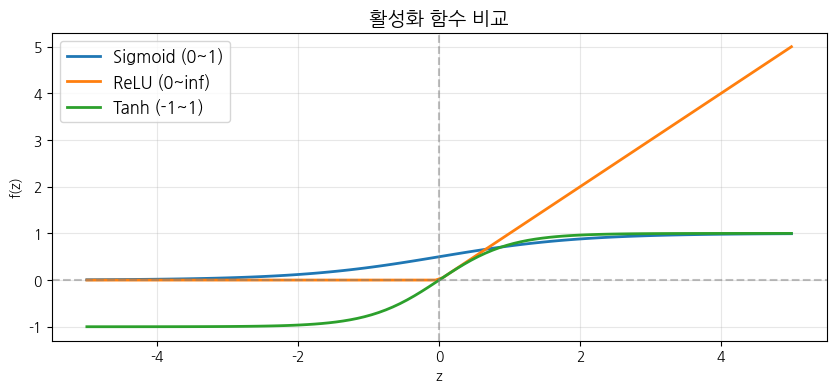

In [22]:
# ✅ 실습 1 정답
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 100)

sigmoid = 1 / (1 + np.exp(-z))
relu = np.maximum(0, z)
tanh = np.tanh(z)

plt.figure(figsize=(10, 4))
plt.plot(z, sigmoid, label="Sigmoid (0~1)", linewidth=2)
plt.plot(z, relu, label="ReLU (0~inf)", linewidth=2)
plt.plot(z, tanh, label="Tanh (-1~1)", linewidth=2)
plt.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
plt.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.title("활성화 함수 비교", fontsize=14)
plt.xlabel("z")
plt.ylabel("f(z)")
plt.show()

### 실습 2: 데이터 추가 + 재학습

In [23]:
# ✏️ 실습 2: 학습 데이터를 추가하고 모델을 재학습시켜 보세요
#
# 문제:
# 1. 아래에 긍정/부정 리뷰를 각 4개씩 추가하세요
# 2. word2idx를 다시 구축하세요 (새 단어가 추가될 수 있으므로)
# 3. 모델을 새로 생성하고 학습시키세요
# 4. 학습 전후의 정확도 변화를 관찰하세요

# 추가할 리뷰 (직접 작성해보세요!)
new_reviews = [
    # ("여기에 긍정 리뷰를 작성하세요", 1),
    # ("여기에 부정 리뷰를 작성하세요", 0),
]

# 전체 데이터 합치기
# all_reviews = reviews + new_reviews

# 이후 위의 6-1 ~ 6-5 과정을 반복하세요!

### 실습 3: 학습 과정 시각화

In [24]:
# ✏️ 실습 3: 학습 과정(손실, 정확도)을 그래프로 시각화하세요
#
# 힌트: 학습 루프에서 매 에포크마다 loss와 accuracy를 리스트에 저장한 뒤
#       matplotlib으로 그리면 됩니다.

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 새 모델 생성
model2 = SentimentLSTM(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)

# 기록용 리스트
loss_history = []
acc_history = []

EPOCHS = 100

for epoch in range(EPOCHS):
    model2.train()
    predictions = model2(X_tensor)
    loss = criterion(predictions, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 기록
    acc = ((predictions >= 0.5).float() == y_tensor).float().mean()
    loss_history.append(loss.item())
    acc_history.append(acc.item())

# 문제: 아래 시각화 코드를 완성하세요
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# ax1.plot(???)
# ax1.set_title("Loss")
# ax2.plot(???)
# ax2.set_title("Accuracy")
# plt.tight_layout()
# plt.show()

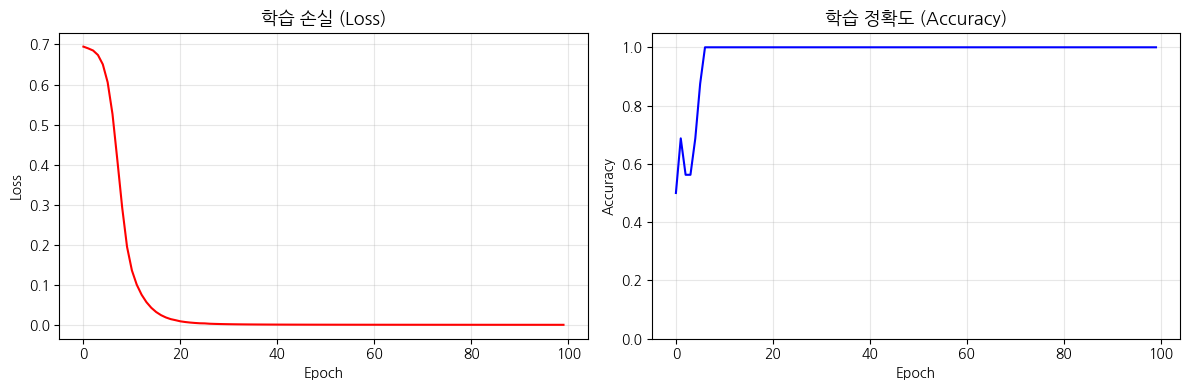

최종 손실: 0.0003
최종 정확도: 100.00%


In [25]:
# ✅ 실습 3 정답
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color="red", linewidth=1.5)
ax1.set_title("학습 손실 (Loss)", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(acc_history, color="blue", linewidth=1.5)
ax2.set_title("학습 정확도 (Accuracy)", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim([0, 1.05])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"최종 손실: {loss_history[-1]:.4f}")
print(f"최종 정확도: {acc_history[-1]:.2%}")

---
## 8. 핵심 정리

### 📌 오늘 배운 개념 정리표

| 개념 | 핵심 | PyTorch 코드 |
|------|------|-------------|
| 신경망 | 입력→가중합→활성화→출력 | `nn.Linear` + `nn.ReLU` |
| 손실 함수 | 예측과 정답의 차이 | `nn.BCELoss()` |
| 역전파 | 기울기를 계산하여 가중치 업데이트 | `loss.backward()` |
| 임베딩 | 단어 정수 → 밀집 벡터 | `nn.Embedding` |
| RNN | 순서를 반영하며 문맥 누적 | `nn.RNN` |
| LSTM | RNN + 장기기억 (게이트 메커니즘) | `nn.LSTM` |

### 📌 학습 루프 핵심 코드

```python
for epoch in range(EPOCHS):
    predictions = model(X)           # 1. 순전파
    loss = criterion(predictions, y) # 2. 손실 계산
    optimizer.zero_grad()            # 3. 기울기 초기화
    loss.backward()                  # 4. 역전파
    optimizer.step()                 # 5. 가중치 업데이트
```

### 🗺 다음 시간 예고 — 7주차: Transformer

```
오늘: LSTM은 단어를 "순서대로" 하나씩 읽는다
     → 문장이 길면 앞쪽 정보가 약해짐
     → 병렬 처리 불가 (느림)

다음: Transformer는 모든 단어를 "동시에" 보고
     → Self-Attention으로 중요한 단어에 집중
     → 병렬 처리 가능 (빠름)
     → GPT, BERT 등 최신 모델의 기반!
```

---
## 📝 과제

### 과제 1: LSTM 하이퍼파라미터 실험

아래 조건을 변경하며 학습 결과를 비교하세요:

1. `EMBEDDING_DIM`을 8, 16, 32로 변경 → 정확도 비교
2. `HIDDEN_DIM`을 16, 32, 64로 변경 → 정확도 비교
3. `learning_rate`를 0.001, 0.01, 0.1로 변경 → 학습 곡선 비교

### 과제 2: 양방향 LSTM (도전)

`nn.LSTM`에 `bidirectional=True`를 추가하면 문장을 **양방향**으로 읽습니다.  
단방향 LSTM과 양방향 LSTM의 성능을 비교해보세요.

```python
# 힌트
self.lstm = nn.LSTM(
    input_size=embedding_dim,
    hidden_size=hidden_dim,
    batch_first=True,
    bidirectional=True  # 양방향!
)
# 주의: 출력 크기가 hidden_dim * 2가 됩니다
self.fc = nn.Linear(hidden_dim * 2, 1)
```